# 03 — IGV Design

**Purpose:** Perform the complete Inlet Guide Vane aerodynamic design. Auto-size rotor blade count B and mid-span chord; select IGV count V with gcd(B,V)=1 to suppress locked Tyler–Sofrin interaction modes; apply Zweifel loading and Carter deviation to set IGV camber and stagger; verify Lieblein DF for the IGV row; establish the rotor inlet velocity triangle.

**Inputs:** Design point fixed in notebook 01.

**Outputs:**
- Annulus dimensions, blade counts B and V
- IGV camber, stagger, solidity, axial chord
- Rotor inlet β₁ at hub / mean / tip
- Pre-swirl sensitivity table
- Axial station positions

**References:** Dixon & Hall (2014); Cumpsty (2004) Ch. 5; Zweifel (1945); Carter (1950) ARC R&M 2804; Tyler & Sofrin (1962).

In [1]:
# Cell 0 — repository path setup
# ─────────────────────────────────────────────────────────────────────────────
# Insert this as the FIRST cell in every notebook.
# Works identically in:
#   • VS Code Jupyter (cwd = workspace root or notebook folder)
#   • JupyterLab browser (JPY_SESSION_NAME points to the .ipynb file)
#   • Classic Jupyter Notebook
#   • Any working directory — does not depend on where the server was started
#
# After this cell runs, both import styles work everywhere:
#   from src.meanline import meanline_analysis   ← old style, unchanged
#   from meanline import meanline_analysis        ← new style, also fine
# ─────────────────────────────────────────────────────────────────────────────

import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")


def _find_repo_root(marker: str = "src") -> Path:
    """
    Find the repository root by walking up from multiple candidate
    starting points.  Tries in order:

    1. Parent of the notebook file itself  (JPY_SESSION_NAME, set by
       JupyterLab — the most reliable anchor in a browser session).
    2. Current working directory  (works when cwd == repo root, e.g.
       VS Code with workspace opened at repo root).
    3. Home directory subtree  (last resort fallback).

    Returns the first directory that contains a `src/` subdirectory.
    """
    jpy = os.environ.get("JPY_SESSION_NAME", "")
    candidates = [
        Path(jpy).parent if jpy else None,   # JupyterLab: notebook dir
        Path.cwd(),                           # VS Code / terminal launch
        Path.home(),                          # last resort
    ]

    seen: set[str] = set()
    for start in candidates:
        if start is None:
            continue
        try:
            p = start.resolve()
        except Exception:
            continue
        for _ in range(8):
            key = str(p)
            if key in seen:
                break
            seen.add(key)
            if (p / marker).is_dir():
                return p
            if p.parent == p:
                break
            p = p.parent

    raise FileNotFoundError(
        f"Cannot find repo root — no '{marker}/' directory found.\n"
        f"  JPY_SESSION_NAME : {jpy!r}\n"
        f"  cwd              : {Path.cwd()}\n"
        f"  Searched up to   : {list(seen)}\n"
        f"Tip: make sure src/ exists in the repository root."
    )


REPO_ROOT = _find_repo_root()
SRC_PATH  = REPO_ROOT / "src"

# Both styles resolve correctly once both paths are on sys.path
for _p in [str(SRC_PATH), str(REPO_ROOT)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── Project imports ────────────────────────────────────────────────────────────
from src.constants import gamma, R, Cp, T0_in, P0_in  # old style — works
from src.meanline  import meanline_analysis, omega_from_RPM
from src.radial    import free_vortex

try:
    from src.plotting import plot_design_maps, plot_velocity_triangles, plot_radial
except Exception:
    pass  # plotting.py needs pandas; skip if not installed

from src.igv import (
    igv_geometry,
    meanline_with_igv,
    print_igv_summary,
    print_rotor_summary,
)
from src.bellmouth import (
    bellmouth_design,
    outer_bellmouth_profile,
    centerbody_profile,
    print_bellmouth_summary,
)
from src.shaft import (
    rotor_mass,
    shaft_sizing,
    bearing_selection,
    campbell_data,
    print_shaft_summary,
    print_bearing_summary,
    print_campbell_summary,
)

# ── Matplotlib style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         10,
})

COLORS = {
    "blue":   "#185FA5",
    "teal":   "#1D9E75",
    "coral":  "#D85A30",
    "purple": "#534AB7",
    "amber":  "#BA7517",
    "gray":   "#5F5E5A",
}

# ── Confirmation ───────────────────────────────────────────────────────────────
print(f"Repo root  : {REPO_ROOT}")
print(f"Src path   : {SRC_PATH}")
print(f"Python     : {sys.version.split()[0]}")
print(f"Launch env : {'JupyterLab (JPY_SESSION_NAME)' if os.environ.get('JPY_SESSION_NAME') else 'VS Code / classic Jupyter (cwd)'}")
print("Imports    : OK")

Repo root  : D:\Dev\rotating-rig-design
Src path   : D:\Dev\rotating-rig-design\src
Python     : 3.10.2
Launch env : JupyterLab (JPY_SESSION_NAME)
Imports    : OK


## 1. Design point IGV geometry

In [2]:
igv = igv_geometry(
    D_tip      = 0.900,
    nu         = 0.75,
    N_RPM      = 3500,
    phi        = 0.725,
    alpha1_deg = 0.0,   # axial inlet — zero pre-swirl at design point
)
print_igv_summary(igv)


  IGV DESIGN SUMMARY

ANNULUS
────────────────────────────────────────────────────────────
  Tip diameter          : 900.0 mm
  Hub diameter          : 675.0 mm
  Hub-to-tip ratio ν    : 0.750
  Mean radius           : 393.8 mm
  Blade height          : 112.5 mm
  Annular area          : 2783.25 cm²
  Tip clearance         : 2.47 mm  (2.2% span)

FLOW CONDITIONS
────────────────────────────────────────────────────────────
  Speed                 : 3500 RPM
  Flow coefficient φ    : 0.7250
  Axial velocity Ca     : 104.63 m/s
  Mean blade speed U    : 144.32 m/s
  Axial Mach number     : 0.3075
  Mass flow ṁ           : 34.042 kg/s

IGV AERODYNAMICS  (mid-span)
────────────────────────────────────────────────────────────
  IGV inlet angle α₀    :  0.0°  (axial)
  IGV exit angle α₁     :  0.0°
  Flow deflection Δα    :  0.0°
  Exit velocity C₁      : 104.63 m/s
  Exit swirl C_θ1       : 0.00 m/s
  Rotor inlet W₁        : 178.25 m/s
  Rotor inlet β₁        : -54.06°

BLADE GEOMETRY  (NAC

## 2. Rotor meanline at design point

In [3]:
rotor = meanline_with_igv(igv, PR=1.10, eta_is=0.85)
print_rotor_summary(rotor)


  ROTOR MEANLINE  (with IGV pre-swirl)
  PR                    : 1.1000
  η_is                  : 0.850
  ΔT₀                   : 9.36 K
  Euler work            : 9.402 kJ/kg
  Shaft power           : 320.1 kW

  ──────────────────────────────────────────────────────
  Quantity                        Inlet         Exit
  ──────────────────────── ──────────── ────────────
  α abs [°]                        0.00        31.91
  β rel [°]                      -54.06       -37.11
  C abs [m/s]                    104.63       123.25
  W rel [m/s]                    178.25       131.21
  Cθ [m/s]                         0.00        65.15

  Work coefficient ψ    : 0.4514  ✓
  Flow coefficient φ    : 0.7250
  De Haller W₂/W₁      : 0.7361  ✓ ≥0.72
  Lieblein DF (rotor)   : 0.4301  ✓ ≤0.45
  Blade turning Δβ      : 16.94°



## 3. Tyler–Sofrin interaction mode check

In [4]:
B = igv['B_blades']
V = igv['V_blades']
print(f'Rotor blades B = {B},  IGV blades V = {V},  gcd(B,V) = {igv["gcd_BV"]}')
print()
print('Tyler–Sofrin modes  m = nB + kV  (lowest |m| first):')
print(f'  {"n":>3} {"k":>4} {"m":>6}')
for n, k, m in igv['ts_modes']:
    flag = '  ← LOCKED (m=0)' if m == 0 else ''
    print(f'  {n:>3} {k:>4} {m:>6}{flag}')
print(f'\nLowest non-zero |m| = {min(abs(x[2]) for x in igv["ts_modes"] if x[2]!=0)}')

Rotor blades B = 37,  IGV blades V = 23,  gcd(B,V) = 1

Tyler–Sofrin modes  m = nB + kV  (lowest |m| first):
    n    k      m
    2   -3      5
    1   -2     -9
    1   -1     14
    2   -2     28
    1   -3    -32
    1    0     37
    3   -3     42
    2   -1     51

Lowest non-zero |m| = 5


## 4. Pre-swirl sensitivity

Sweep IGV exit angle α₁ from –15° to +15° to understand how pre-swirl affects rotor loading and inlet relative angle.

In [5]:
alpha_range = np.linspace(-15, 15, 13)
rows = []

print(f'  {"α₁ [°]":>7} {"β₁ [°]":>8} {"W₁ [m/s]":>10} {"ψ":>8} {"DH":>8} {"DF":>8} {"P [kW]":>8}')
print('  ' + '─'*62)

for a1 in alpha_range:
    g  = igv_geometry(D_tip=0.900, nu=0.75, N_RPM=3500, phi=0.725, alpha1_deg=a1)
    rr = meanline_with_igv(g, PR=1.10, eta_is=0.85)
    ok = '✓' if rr['DH_ok'] and rr['DF_ok'] else '⚠'
    print(f'  {a1:>7.1f} {rr["beta1_deg"]:>8.2f} {rr["W1_m_s"]:>10.2f}'
          f' {rr["psi"]:>8.4f} {rr["De_Haller"]:>8.4f}'
          f' {rr["DF_rotor"]:>8.4f} {rr["P_shaft_kW"]:>8.1f}  {ok}')
    rows.append((a1, rr['beta1_deg'], rr['W1_m_s'], rr['psi'],
                 rr['De_Haller'], rr['DF_rotor'], rr['P_shaft_kW']))

   α₁ [°]   β₁ [°]   W₁ [m/s]        ψ       DH       DF   P [kW]
  ──────────────────────────────────────────────────────────────
    -15.0   -58.74     201.63   0.4514   0.7430   0.4039    320.1  ✓
    -12.5   -58.01     197.50   0.4514   0.7411   0.4088    320.1  ✓
    -10.0   -57.27     193.49   0.4514   0.7395   0.4135    320.1  ✓
     -7.5   -56.50     189.58   0.4514   0.7382   0.4180    320.1  ✓
     -5.0   -55.72     185.74   0.4514   0.7372   0.4223    320.1  ✓
     -2.5   -54.90     181.97   0.4514   0.7364   0.4263    320.1  ✓
      0.0   -54.06     178.25   0.4514   0.7361   0.4301    320.1  ✓
      2.5   -53.18     174.58   0.4514   0.7361   0.4336    320.1  ✓
      5.0   -52.26     170.93   0.4514   0.7365   0.4367    320.1  ✓
      7.5   -51.29     167.30   0.4514   0.7375   0.4395    320.1  ✓
     10.0   -50.26     163.68   0.4514   0.7391   0.4418    320.1  ✓
     12.5   -49.18     160.06   0.4514   0.7414   0.4436    320.1  ✓
     15.0   -48.02     156.42   0.4514   

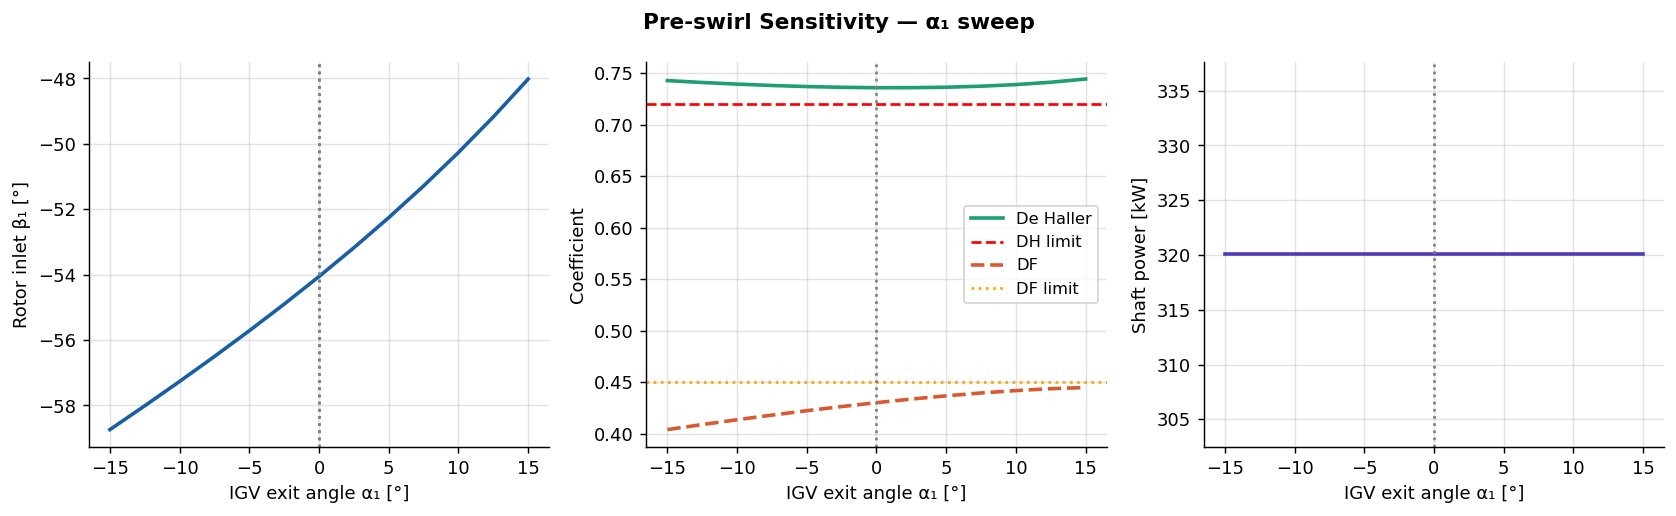

In [6]:
rows = np.array(rows)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Pre-swirl Sensitivity — α₁ sweep', fontweight='bold')

axes[0].plot(rows[:,0], rows[:,1], '#185FA5', lw=2)
axes[0].set(xlabel='IGV exit angle α₁ [°]', ylabel='Rotor inlet β₁ [°]')
axes[0].axvline(0, color='gray', ls=':')

axes[1].plot(rows[:,0], rows[:,4], '#1D9E75', lw=2, label='De Haller')
axes[1].axhline(0.72, color='red', ls='--', label='DH limit')
axes[1].plot(rows[:,0], rows[:,5], '#D85A30', lw=2, ls='--', label='DF')
axes[1].axhline(0.45, color='orange', ls=':', label='DF limit')
axes[1].set(xlabel='IGV exit angle α₁ [°]', ylabel='Coefficient')
axes[1].legend(fontsize=9)

axes[2].plot(rows[:,0], rows[:,6], '#533AB7', lw=2)
axes[2].set(xlabel='IGV exit angle α₁ [°]', ylabel='Shaft power [kW]')

for ax in axes:
    ax.grid(True, alpha=0.35)
    ax.axvline(0, color='gray', ls=':')
plt.tight_layout()
plt.savefig('../figures/03_preswirl_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Spanwise velocity triangles at rotor inlet

Show how β₁ varies from hub to tip as computed by the IGV free-vortex exit.

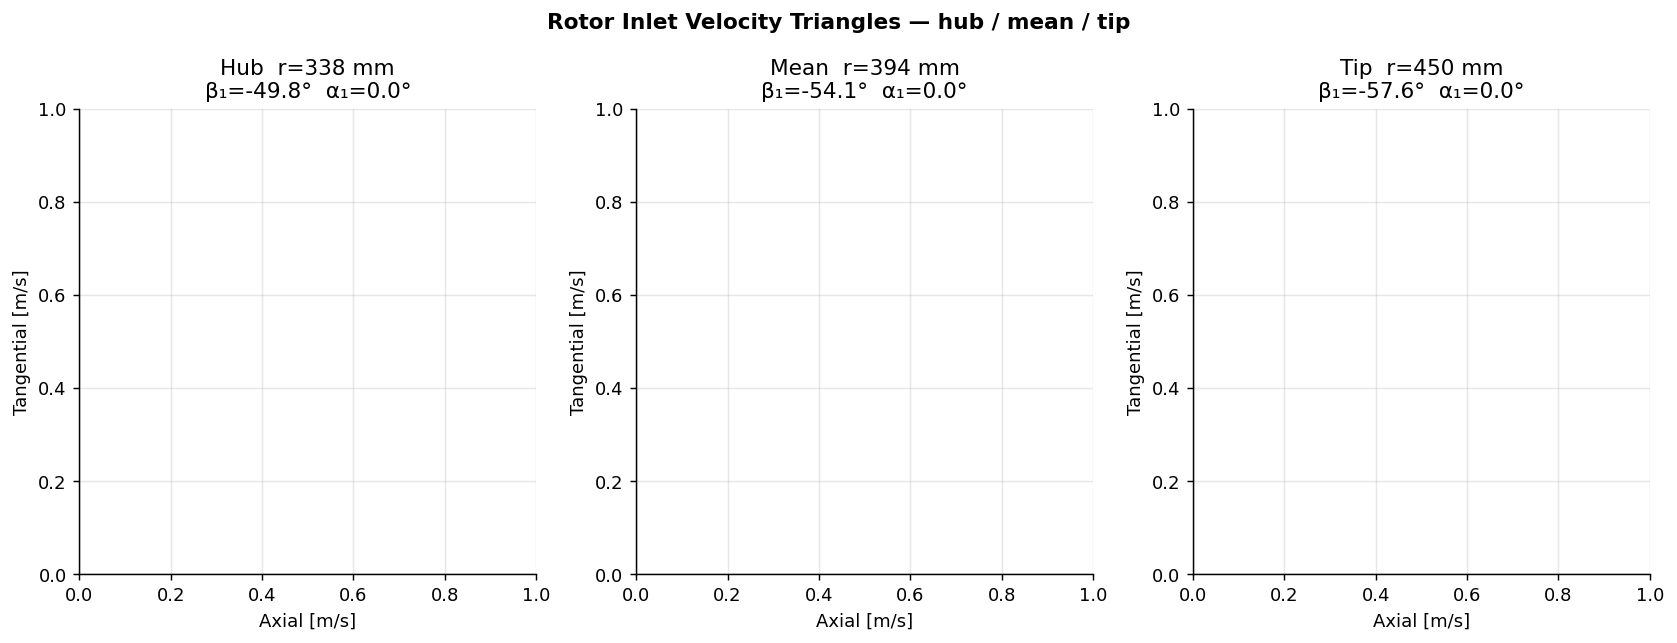

In [7]:
stations = igv['stations']
labels   = ['hub', 'mean', 'tip']
colors   = ['#D85A30', '#185FA5', '#1D9E75']

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Rotor Inlet Velocity Triangles — hub / mean / tip', fontweight='bold')

for ax, lbl, col in zip(axes, labels, colors):
    st = stations[lbl]
    Ca = st['Ca_m_s']
    U  = st['U_m_s']
    Ct = st['C_theta1']
    # Vectors: Ca (axial), Ct (tangential), U (blade speed)
    # Absolute: C1 = (Ca, Ct)
    # Relative: W1 = (Ca, Ct-U)
    ax.annotate('', xy=(Ca, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='k', lw=1.5))
    ax.annotate('', xy=(Ca, Ct), xytext=(Ca, 0),
                arrowprops=dict(arrowstyle='->', color='#185FA5', lw=1.5))
    ax.annotate('', xy=(Ca, Ct-U), xytext=(Ca, 0),
                arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5))
    ax.annotate('', xy=(0, -U), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#854F0B', lw=1.5))
    ax.set(xlabel='Axial [m/s]', ylabel='Tangential [m/s]',
           title=f'{lbl.capitalize()}  r={st["r_mm"]:.0f} mm\n'
                 f'β₁={st["beta1_deg"]:.1f}°  α₁={st["alpha1_deg"]:.1f}°')
    ax.axhline(0, color='gray', lw=0.7)
    ax.axvline(0, color='gray', lw=0.7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/03_inlet_velocity_triangles.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Axial station map

In [8]:
print('Axial station map  (x = 0 at rotor LE, upstream = negative)')
print('─' * 55)
print(f'  IGV TE → rotor LE gap : {igv["axial_gap_mm"]:.1f} mm')
print(f'  IGV axial chord       : {igv["igv_axial_len_mm"]:.1f} mm')
print(f'  IGV LE position       : x = {-igv["igv_LE_to_rotor_LE_mm"]:.1f} mm')
print(f'  IGV TE position       : x = {-igv["axial_gap_mm"]:.1f} mm')
print(f'  Rotor LE              : x = 0 mm  ◀ reference')

Axial station map  (x = 0 at rotor LE, upstream = negative)
───────────────────────────────────────────────────────
  IGV TE → rotor LE gap : 82.5 mm
  IGV axial chord       : 107.6 mm
  IGV LE position       : x = -190.1 mm
  IGV TE position       : x = -82.5 mm
  Rotor LE              : x = 0 mm  ◀ reference


---
**Proceed to** `04_inlet_bellmouth.ipynb`.